In [2]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [28]:
def traer_id_variable():
    url = 'https://api.bcra.gob.ar/estadisticas/v3.0/monetarias'
    r = requests.get(url, verify=False)
    
    if r.status_code == 200:
        datos=r.json()
        results= datos['results']
        
        for item in results:
            print(item['idVariable'], item['descripcion'])
        
        print(results)
    else:
        print(f"Error al obtener los datos: {r.status_code}")
        return None

traer_id_variable()



1 Reservas Internacionales del BCRA (en millones de dólares - cifras provisorias sujetas a cambio de valuación)
4 Tipo de Cambio Minorista ($ por USD) Comunicación B 9791 - Promedio vendedor
5 Tipo de Cambio Mayorista ($ por USD) Comunicación A 3500 - Referencia
6 Tasa de Política Monetaria (en % n.a.)
7 BADLAR en pesos de bancos privados (en % n.a.)
8 TM20 en pesos de bancos privados (en % n.a.)
9 Tasas de interés de las operaciones de pase activas para el BCRA, a 1 día de plazo (en % n.a.)
10 Tasas de interés de las operaciones de pase pasivas para el BCRA, a 1 día de plazo (en % n.a.)
11 Tasas de interés por préstamos entre entidades financiera privadas (BAIBAR) (en % n.a.)
12 Tasas de interés por depósitos a 30 días de plazo en entidades financieras (en % n.a.)
13 Tasa de interés de préstamos por adelantos en cuenta corriente
14 Tasa de interés de préstamos personales
15 Base monetaria - Total (en millones de pesos)
16 Circulación monetaria (en millones de pesos)
17 Billetes y mone

/home/devenzo35/anaconda3/lib/python3.12/site-packages/urllib3/connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.bcra.gob.ar'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


/home/devenzo35/anaconda3/lib/python3.12/site-packages/urllib3/connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.bcra.gob.ar'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/home/devenzo35/anaconda3/lib/python3.12/site-packages/urllib3/connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.bcra.gob.ar'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


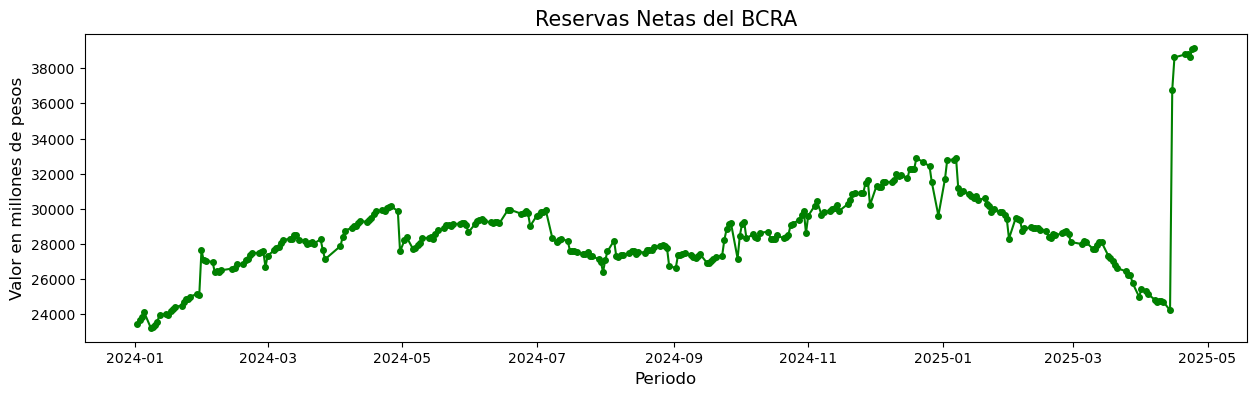

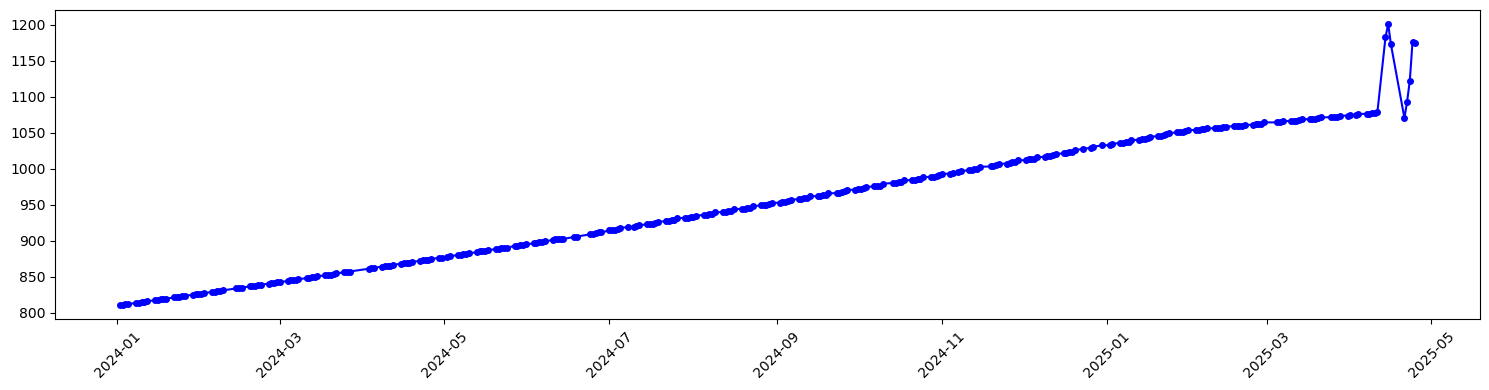

In [48]:
def traer_serie_bcra():
    url1 = 'https://api.bcra.gob.ar/estadisticas/v3.0/monetarias/1?desde=2024-01-01&hasta=2025-04-25&limit=1000'
    r1 = requests.get(url1, verify=False)

    url2 = 'https://api.bcra.gob.ar/estadisticas/v3.0/monetarias/5?desde=2024-01-01&hasta=2025-04-25&limit=1000'
    r2 = requests.get(url2, verify=False)

    if r1.status_code == 200 & r2.status_code == 200:
        datos_reservas = r1.json()
        cambio_oficial = r2.json()
        
        resultados = datos_reservas['results']

        fechas = []
        valores_reservas = []
        valores_cambio = []

        for item in datos_reservas['results']:
            fechas.append(item['fecha'])
            valores_reservas.append(item['valor'])
            

        for item in cambio_oficial['results']:          
            valores_cambio.append(item['valor'])   
        
        fechas = pd.to_datetime(fechas)

        plt.figure(figsize=(15,4))
        plt.plot(fechas, valores_reservas, marker='o', color='g', linestyle='-', markersize='4')
        
        plt.title('Reservas Netas del BCRA', fontsize=15)
        plt.xlabel('Periodo', fontsize=12)
        plt.ylabel('Valor en millones de pesos', fontsize=12)

        plt.figure(figsize=(15,4))
        plt.plot(fechas, valores_cambio, marker='o', color='b', linestyle='-', markersize='4')
        
        plt.xticks(rotation=45)
        plt.tight_layout()
        
        plt.show()
        
    else:
        print(f"Error al obtener los datos: {r.status_code}")
        return None
    


traer_serie_bcra()